# Лабораторная работа №1. EDA данных FishGrow
Цель: изучить схему данных, найти проблемы качества, сформулировать
гипотезы о признаках и правило разбиения без утечек.
Модель в этой работе не обучается; тестовая выборка не используется.

## 0. Окружение и загрузка данных

In [1]:
import sys, platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

print("Python:", sys.version.split()[0], "|", platform.platform())
for lib in (pd, np, matplotlib, sns):
    print(f"{lib.__name__}: {lib.__version__}")

FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

Python: 3.9.13 | Windows-10-10.0.26200-SP0
pandas: 1.3.5
numpy: 1.21.6
matplotlib: 3.8.4
seaborn: 0.13.2


In [2]:
DATA_PATH = Path("../assets/data/Fish.csv")
df = pd.read_csv(DATA_PATH)

assert not df.empty, "Таблица пустая"
assert df.columns.is_unique, "Повторяющиеся имена столбцов"
print("Форма:", df.shape)
df.head()

Форма: (159, 7)


,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


## 1. Паспорт данных

In [3]:
# Гипотеза: Height и Width вычислены как процент (с 1 знаком) от Length3
for col in ["Height", "Width"]:
    pct = df[col] / df["Length3"] * 100
    share_round = (pct - pct.round(1)).abs().lt(0.01).mean()
    print(f"{col}: доля строк, где процент от Length3 целый до 0.1 — {share_round:.1%}")

Height: доля строк, где процент от Length3 целый до 0.1 — 100.0%
Width: доля строк, где процент от Length3 целый до 0.1 — 100.0%


**Вывод.** Для 100 % строк (159 из 159) Height и Width равны
«процент с точностью 0,1» × Length3 / 100. Значит, в исходных данных
высота и ширина хранились в процентах от полной длины, а в этой
таблице пересчитаны в единицы длины.

Следствия:
- Height и Width — вычисленные поля; их точность ограничена
  округлением процента, а не точностью измерения;
- их единицы совпадают с единицами Length3;
- Height и Width связаны с Length3 по построению, что усиливает
  мультиколлинеарность признаков.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,159.0,398.326415,357.978317,0.0000,120.00000,273.0000,650.0000,1650.000
Length1,159.0,26.247170,9.996441,7.5000,19.05000,25.2000,32.7000,59.000
Length2,159.0,28.415723,10.716328,8.4000,21.00000,27.3000,35.5000,63.400
Length3,159.0,31.227044,11.610246,8.8000,23.15000,29.4000,39.6500,68.000
Height,159.0,8.970994,4.286208,1.7284,5.94480,7.7860,12.3659,18.957
Width,159.0,4.417486,1.685804,1.0476,3.38565,4.2485,5.5845,8.142


In [6]:
df["Species"].value_counts()

Perch        56
Bream        35
Roach        20
Pike         17
Smelt        14
Parkki       11
Whitefish     6
Name: Species, dtype: int64

In [7]:
df["Species"].map(repr).unique()

array(["'Bream'", "'Roach'", "'Whitefish'", "'Parkki'", "'Perch'",
       "'Pike'", "'Smelt'"], dtype=object)

**Наблюдения.**
- 159 строк × 7 столбцов, пропусков нет, типы корректны.
- Species: 7 категорий без скрытых пробелов и вариантов написания;
  сильный дисбаланс — от 56 (Perch, 35 %) до 6 (Whitefish, 3,8 %).
- Weight: минимум 0 г — физически невозможное значение (аномалия).
- Weight скошена вправо: среднее 398 г > медиана 273 г.
- Единицы: длины 8,8–68 — правдоподобны только в сантиметрах
  (в мм — слишком малы для массы до 1,6 кг, в дм — слишком велики);
  масса 0–1650 — правдоподобна в граммах.

In [8]:
df[df["Weight"] == 0]

,Species,Weight,Length1,Length2,Length3,Height,Width
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516


In [9]:
roach = df[df["Species"] == "Roach"]
roach[(roach["Length3"] - 22.8).abs() <= 2].sort_values("Length3")

,Species,Weight,Length1,Length2,Length3,Height,Width
37,Roach,78.0,17.5,18.8,21.2,5.5756,2.9044
38,Roach,87.0,18.2,19.8,22.2,5.6166,3.1746
39,Roach,120.0,18.6,20.0,22.2,6.2160,3.5742
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516
41,Roach,110.0,19.1,20.8,23.1,6.1677,3.3957
42,Roach,120.0,19.4,21.0,23.7,6.1146,3.2943
44,Roach,145.0,20.5,22.0,24.3,6.6339,3.5478
43,Roach,150.0,20.4,22.0,24.7,5.8045,3.7544


**Аномалия: строка 40 (Roach), Weight = 0 г.** Длины (19,0 / 20,5 / 22,8)
и пропорции тела правдоподобны и согласуются с другими особями плотвы;
рыбы того же вида близкой длины весят около 78–150 г. Масса 0 физически
невозможна — вероятна ошибка ввода или пропуск, записанный нулём.
Исправить по источнику нельзя (первичных записей нет).
**Решение:** исключить строку из обучения и оценки модели как целевое
значение-ошибку; в исходных данных не изменять.

### Паспорт данных

Единица наблюдения: одна рыба (предположение — идентификатора нет).
Размер: 159 строк × 7 столбцов. Пропусков нет.

| Поле | Смысл | Тип | Единицы | Роль | Пропуски | Диапазон / словарь | Источник | Что проверить |
|---|---|---|---|---|---|---|---|---|
| Species | вид рыбы | категориальный | словарь | признак; группа для стратификации | нет | 7 видов: Perch 56, Bream 35, Roach 20, Pike 17, Smelt 14, Parkki 11, Whitefish 6 | запись при улове | редкие виды, новые виды при эксплуатации |
| Weight | масса рыбы | числовой (float64; в README автора — int) | г (README автора; согласуется с диапазоном) | целевая | нет | 0–1650; > 0; 0 в строке 40 — аномалия | Kaggle Fish Market (Aung Pyae), по README автора | нули |
| Length1 | длина; в README — «Vertical length», трактовка неоднозначна | числовой (float64) | см (README) | признак | нет | 7,5–59,0 | README автора | L1 ≤ L2 |
| Length2 | длина; в README — «Diagonal length» | числовой | см (README) | признак | нет | 8,4–63,4 | README автора | L1 ≤ L2 ≤ L3 |
| Length3 | длина; в README — «Cross length» | числовой | см (README) | признак | нет | 8,8–68,0 | README автора | согласованность |
| Height | высота; в README — «Height» | числовой | см (README) | признак | нет | 1,73–18,96 | вычисление: % × Length3 / 100 (проверено; в README не указано) | зависимость от Length3 |
| Width | ширина; в README — «Diagonal width» | числовой | см (README) | признак | нет | 1,05–8,14 | вычисление: % × Length3 / 100 (проверено; в README не указано) | зависимость от Length3 |

**Единица независимого наблюдения.** Предполагается, что одна строка —
одна рыба. В данных нет идентификатора рыбы, партии, водоёма или даты,
поэтому проверить, относятся ли строки к одному объекту, партии или
моменту времени, невозможно. Строки упорядочены по видам, что отражает
порядок записи, но не структуру партий. Повторные измерения одной рыбы
косвенно проверяются поиском дубликатов и почти одинаковых строк
(раздел 2). Групповое разбиение невозможно из-за отсутствия группирующего
признака; независимость строк — допущение (см. «Риски»).

## 2. Проверки качества

In [10]:
import sys
sys.path.insert(0, str(Path("..").resolve()))

from src import data_checks as dc

In [11]:
schema_problems = dc.check_schema(df)
print(schema_problems or "Схема совпадает с ожидаемой")

Схема совпадает с ожидаемой


In [12]:
summary = dc.run_row_checks(df)
summary

,check,n_rows,rows
0,полные дубликаты,0,[]
1,пропуски / бесконечности,0,[]
2,значения <= 0,1,[40]
3,порядок длин,0,[]
4,пропорции тела,0,[]


In [13]:
pd.concat([dc.check_non_positive(df),
           dc.check_length_order(df),
           dc.check_proportions(df)])

,Species,Weight,Length1,Length2,Length3,Height,Width,issue
40,Roach,0.0,19.0,20.5,22.8,6.4752,3.3516,Weight <= 0


In [14]:
dc.check_rare_categories(df)

,count,share,rare
Perch,56,0.352201,False
Bream,35,0.220126,False
Roach,20,0.125786,False
Pike,17,0.106918,False
Smelt,14,0.088050,False
Parkki,11,0.069182,False
Whitefish,6,0.037736,True


In [15]:
near = dc.check_near_duplicates(df, threshold=0.05)
print(f"Пар почти-дубликатов: {len(near)}")
near

Пар почти-дубликатов: 4


,row_a,row_b,Species,distance
0,25,26,Bream,0.0417
1,103,104,Perch,0.0304
2,149,150,Smelt,0.0334
3,152,153,Smelt,0.0252


In [16]:
dc.check_unique_columns(df)

,nunique,unique_ratio,id_candidate
Species,7,0.044025,False
Weight,101,0.635220,False
Length1,116,0.729560,False
Length2,93,0.584906,False
Length3,124,0.779874,False
Height,154,0.968553,False
Width,152,0.955975,False


In [17]:
for a, b in near[["row_a", "row_b"]].itertuples(index=False):
    display(df.loc[[a, b]])

,Species,Weight,Length1,Length2,Length3,Height,Width
25,Bream,725.0,31.8,35.0,40.9,16.3600,6.0532
26,Bream,720.0,32.0,35.0,40.6,16.3618,6.0900


,Species,Weight,Length1,Length2,Length3,Height,Width
103,Perch,260.0,25.4,27.5,28.9,7.1672,4.335
104,Perch,265.0,25.4,27.5,28.9,7.0516,4.335


,Species,Weight,Length1,Length2,Length3,Height,Width
149,Smelt,9.8,10.7,11.2,12.4,2.0832,1.2772
150,Smelt,8.7,10.8,11.3,12.6,1.9782,1.2852


,Species,Weight,Length1,Length2,Length3,Height,Width
152,Smelt,9.9,11.3,11.8,13.1,2.2139,1.1659
153,Smelt,9.8,11.4,12.0,13.2,2.2044,1.1484


**Результаты проверок качества.**
- Схема совпадает с ожидаемой; пропусков, бесконечностей и полных
  дубликатов нет.
- Значения ≤ 0: одна строка — 40 (Roach, Weight = 0), см. раздел 1.
- Порядок Length1 ≤ Length2 ≤ Length3 выполняется во всех 159 строках —
  косвенное подтверждение того, что длины измерены до всё более дальних
  точек тела.
- Пропорции тела корректны: Height и Width меньше Length3 во всех строках.
- Редкая категория: Whitefish (6 строк, 3,8 %).
- Кандидатов в идентификаторы нет. Высокая уникальность Height и Width
  (≈ 97 %) объясняется их вычисленным характером (4 знака после запятой),
  а не ролью идентификатора.
- Почти-дубликаты (порог 0,05 ст. откл.): 4 пары соседних строк —
  25/26 (Bream), 103/104 (Perch), 149/150 и 152/153 (Smelt).
  Во всех парах различаются масса и хотя бы часть размеров, поэтому
  это не копии записи. Соседство объясняется порядком записи
  (внутри вида по размеру). Наиболее подозрительна пара 103/104:
  три длины и ширина совпадают, но масса (260 / 265 г) и высота
  различаются — вероятно, две рыбы одного размера.

  **Решение:** строки оставить; пару 103/104 при разбиении держать
  в одной части выборки как возможное повторное измерение.

## 3. Визуализация

In [18]:
# ===== Ячейка 3.0 — настройки графиков =====
SPECIES_ORDER = ["Perch", "Bream", "Roach", "Pike", "Smelt", "Parkki", "Whitefish"]  # по численности
PALETTE = dict(zip(SPECIES_ORDER,
                   ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7"]))
MARKERS = dict(zip(SPECIES_ORDER, ["o", "s", "^", "D", "v", "P", "X"]))  # форма дублирует цвет
 
UNITS = {"Weight": "масса, г", "Length1": "Length1, см", "Length2": "Length2, см",
         "Length3": "Length3, см", "Height": "высота, см", "Width": "ширина, см"}
 
sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False})
 
def save(fig, name):
    """Сохраняет рисунок в reports/figures/ для отчёта."""
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

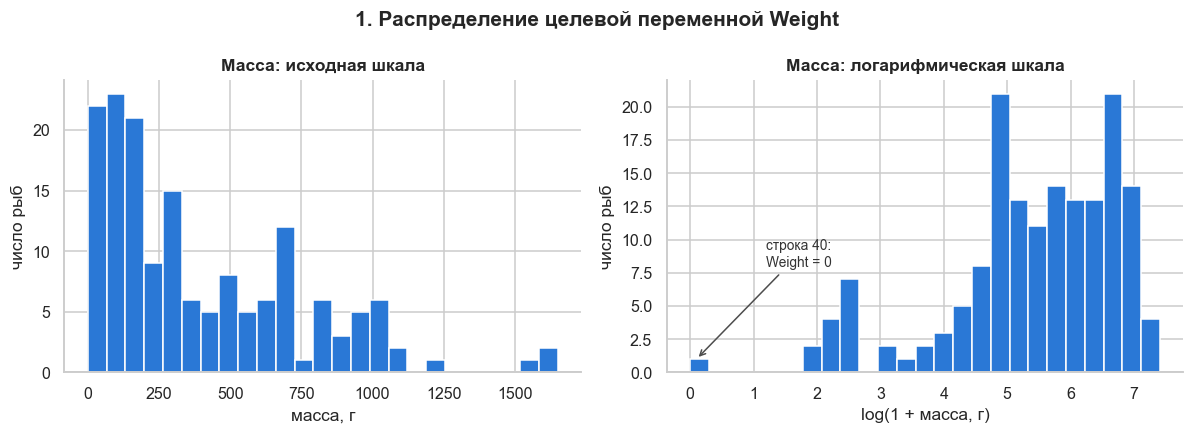

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df["Weight"], bins=25, color="#2a78d6", edgecolor="white")
axes[0].set(title="Масса: исходная шкала", xlabel="масса, г", ylabel="число рыб")
axes[1].hist(np.log1p(df["Weight"]), bins=25, color="#2a78d6", edgecolor="white")
axes[1].set(title="Масса: логарифмическая шкала", xlabel="log(1 + масса, г)", ylabel="число рыб")
axes[1].annotate("строка 40:\nWeight = 0", xy=(0.1, 1), xytext=(1.2, 8),
                 arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9, color="0.2")
fig.suptitle("1. Распределение целевой переменной Weight", fontweight="bold")
fig.tight_layout(); save(fig, "01_weight_distribution"); plt.show()

**Вывод.** В исходной шкале масса сильно скошена вправо: основная часть рыб
легче 500 г (медиана 273 г, среднее 398 г), несколько крупных особей
(до 1650 г) образуют длинный правый хвост. После логарифмирования
распределение становится ближе к симметричному. Отдельно у нуля
находится строка 40 (Weight = 0) — невозможное значение.
Следствие: при моделировании целесообразно предсказывать log(масса),
тогда ошибки становятся относительными и мелкие рыбы не теряются
на фоне крупных.

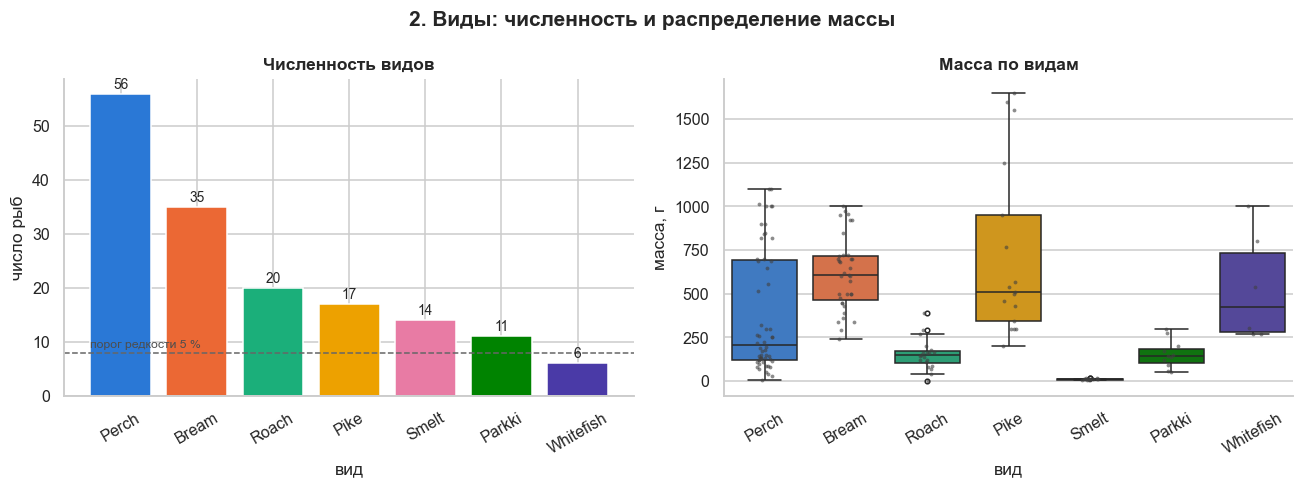

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
counts = df["Species"].value_counts().reindex(SPECIES_ORDER)
axes[0].bar(counts.index, counts.values, color=[PALETTE[s] for s in counts.index])
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha="center", fontsize=9)
axes[0].axhline(len(df) * 0.05, ls="--", color="0.4", lw=1)
axes[0].text(-0.4, len(df) * 0.05 + 1, "порог редкости 5 %", ha="left", fontsize=8, color="0.3")
axes[0].set(title="Численность видов", xlabel="вид", ylabel="число рыб")
 
sns.boxplot(data=df, x="Species", y="Weight", order=SPECIES_ORDER, hue="Species",
            palette=PALETTE, legend=False, ax=axes[1], fliersize=3)
sns.stripplot(data=df, x="Species", y="Weight", order=SPECIES_ORDER,
              color="0.25", size=2.5, alpha=0.6, ax=axes[1])
axes[1].set(title="Масса по видам", xlabel="вид", ylabel="масса, г")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
fig.suptitle("2. Виды: численность и распределение массы", fontweight="bold")
fig.tight_layout(); save(fig, "02_species"); plt.show()

**Вывод.** Виды сильно несбалансированы: от 56 особей (Perch, 35 %) до 6
(Whitefish, 3,8 %); Whitefish — ниже порога редкости 5 %, при разбиении
в тестовую выборку попадёт 1 особь. Масса сильно зависит от вида:
Smelt — до ~20 г, Pike — до 1650 г; наибольший разброс массы у Pike
и Perch, наименьший — у Smelt и Parkki. Строка 40 видна как нижний
выброс у Roach. Следствия: вид — важный признак; выбросы нужно искать
внутри вида; разбиение — стратифицированное по виду.

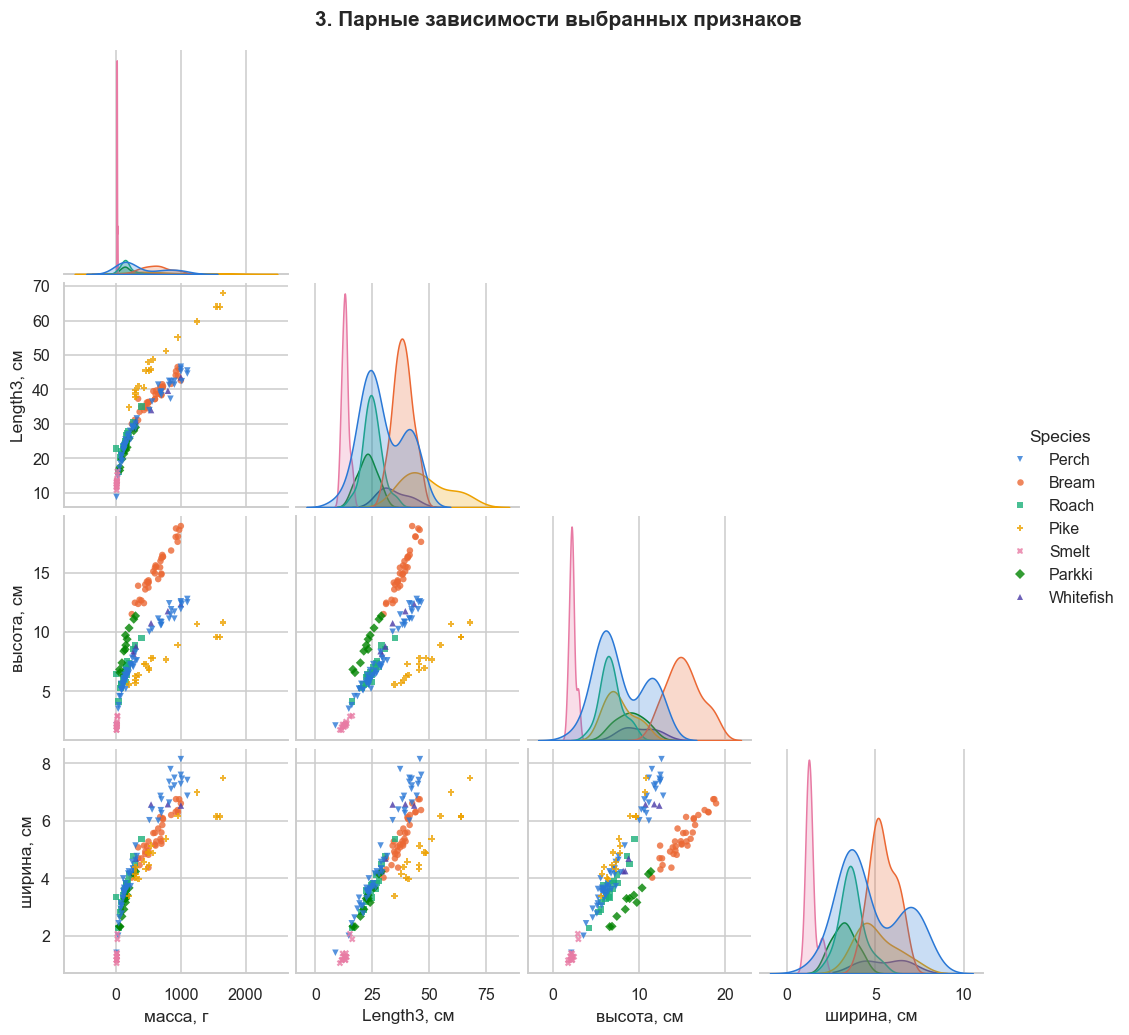

In [21]:
pair_cols = ["Weight", "Length3", "Height", "Width"]
g = sns.pairplot(df[pair_cols + ["Species"]].rename(columns=UNITS),
                 hue="Species", hue_order=SPECIES_ORDER, palette=PALETTE,
                 markers=[MARKERS[s] for s in SPECIES_ORDER],
                 plot_kws=dict(s=18, alpha=0.8, linewidth=0), height=2.3, corner=True)
g.figure.suptitle("3. Парные зависимости выбранных признаков", fontweight="bold", y=1.02)
save(g.figure, "03_pairplot"); plt.show()

**Вывод.** Связь массы с длиной, высотой и шириной нелинейная (масса
растёт быстрее размеров) и различается по видам: при одинаковой длине
Pike заметно легче Bream и Perch. На графике «высота — длина» виды
образуют отдельные лучи с разным наклоном: пропорции тела видоспецифичны
(Bream — высокий, Pike и Smelt — вытянутые). Внутри вида размеры связаны
почти линейно — признак коллинеарности. Length1 и Length2 не показаны:
они практически дублируют Length3.

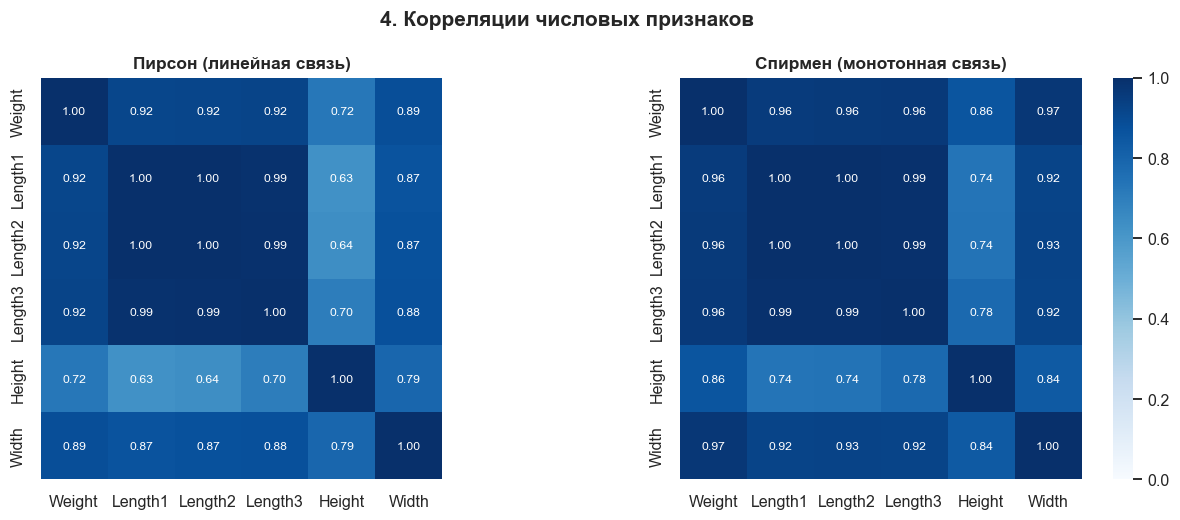

In [22]:
num_cols = ["Weight", "Length1", "Length2", "Length3", "Height", "Width"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, method, title in zip(axes, ["pearson", "spearman"],
                             ["Пирсон (линейная связь)", "Спирмен (монотонная связь)"]):
    corr = df[num_cols].corr(method=method)
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1,
                square=True, cbar=ax is axes[1], ax=ax, annot_kws={"size": 8})
    ax.set_title(title)
fig.suptitle("4. Корреляции числовых признаков", fontweight="bold")
fig.tight_layout(); save(fig, "04_correlations"); plt.show()

**Вывод.** Все размеры сильно связаны с массой (Пирсон: Length3 —
[≈ 0,92], Width — [≈ 0,89], Height — [≈ 0,72]). Коэффициенты Спирмена
выше, чем Пирсона: зависимость монотонная, но нелинейная, и Пирсон её
недооценивает. Length1, Length2 и Length3 коррелируют практически
полностью (≈ 0,99) — мультиколлинеарность. Height связана с остальными
признаками слабее, так как отражает форму тела, зависящую от вида.
Оговорка: корреляция по всей таблице смешивает виды и не доказывает
причинной связи.

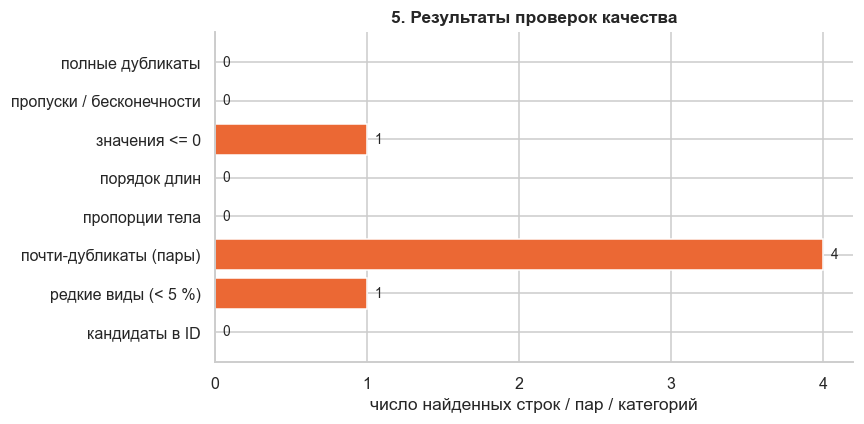

In [23]:
quality = dc.run_row_checks(df)[["check", "n_rows"]].copy()
extra = pd.DataFrame({
    "check": ["почти-дубликаты (пары)", "редкие виды (< 5 %)", "кандидаты в ID"],
    "n_rows": [len(dc.check_near_duplicates(df)),
               int(dc.check_rare_categories(df)["rare"].sum()),
               int(dc.check_unique_columns(df)["id_candidate"].sum())],
})
quality = pd.concat([quality, extra], ignore_index=True)
 
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#eb6834" if n > 0 else "#b8b8b0" for n in quality["n_rows"]]
ax.barh(quality["check"], quality["n_rows"], color=colors)
for y, n in enumerate(quality["n_rows"]):
    ax.text(n + 0.05, y, str(n), va="center", fontsize=9)
ax.invert_yaxis()
ax.set(title="5. Результаты проверок качества", xlabel="число найденных строк / пар / категорий",
       ylabel="")
ax.xaxis.get_major_locator().set_params(integer=True)
fig.tight_layout(); save(fig, "05_quality"); plt.show()

**Вывод.** Данные в целом чистые: пропусков, бесконечностей, полных
дубликатов, нарушений порядка Length1 ≤ Length2 ≤ Length3 и невозможных
пропорций тела нет. Найдены: одно невозможное значение (строка 40,
Weight = 0), четыре пары почти одинаковых строк (разобраны в разделе 2 —
разные рыбы, пара 103/104 держится в одной части разбиения) и одна
редкая категория (Whitefish). Кандидатов в идентификаторы нет.

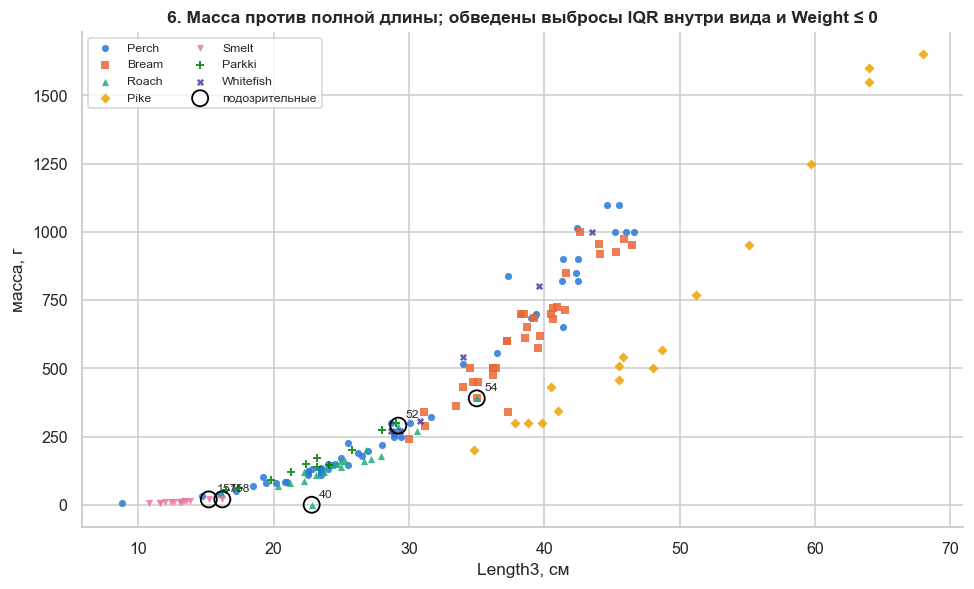

Помеченные строки: [40, 52, 54, 157, 158]


In [24]:
def iqr_mask(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    return (s < q1 - k * (q3 - q1)) | (s > q3 + k * (q3 - q1))
 
flag = df.groupby("Species")["Weight"].transform(iqr_mask).astype(bool) | (df["Weight"] <= 0)
 
fig, ax = plt.subplots(figsize=(9, 5.5))
for s in SPECIES_ORDER:
    part = df[df["Species"] == s]
    ax.scatter(part["Length3"], part["Weight"], s=22, color=PALETTE[s],
               marker=MARKERS[s], label=s, alpha=0.85, linewidths=0)
ax.scatter(df.loc[flag, "Length3"], df.loc[flag, "Weight"], s=110,
           facecolors="none", edgecolors="black", linewidths=1.2, label="подозрительные")
for i, r in df[flag].iterrows():
    ax.annotate(str(i), (r["Length3"], r["Weight"]), xytext=(5, 5),
                textcoords="offset points", fontsize=8)
ax.set(title="6. Масса против полной длины; обведены выбросы IQR внутри вида и Weight ≤ 0",
       xlabel="Length3, см", ylabel="масса, г")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); save(fig, "06_outliers"); plt.show()
print("Помеченные строки:", sorted(df.index[flag].tolist()))

**Вывод.** По правилу IQR внутри вида и условию Weight ≤ 0 помечены строки
40, 52, 54, 157, 158. Строки 52 и 54 (крупнейшая плотва), 157 и 158
(крупнейшая корюшка) лежат на общей кривой масса–длина: это крупные
особи с нормальными пропорциями — выбросы по массе, но не ошибки.
Строка 40 (длина 22,8 см, масса 0) выпадает из зависимости — ошибка
ввода. Pike образует отдельную ветвь ниже общего облака — особенность
вида (вытянутое тело), а не выброс. Одномерный IQR по массе не учитывает
размер рыбы, поэтому в разделе 4 дополнительно оценивается отклонение
массы от ожидаемой при данной длине.

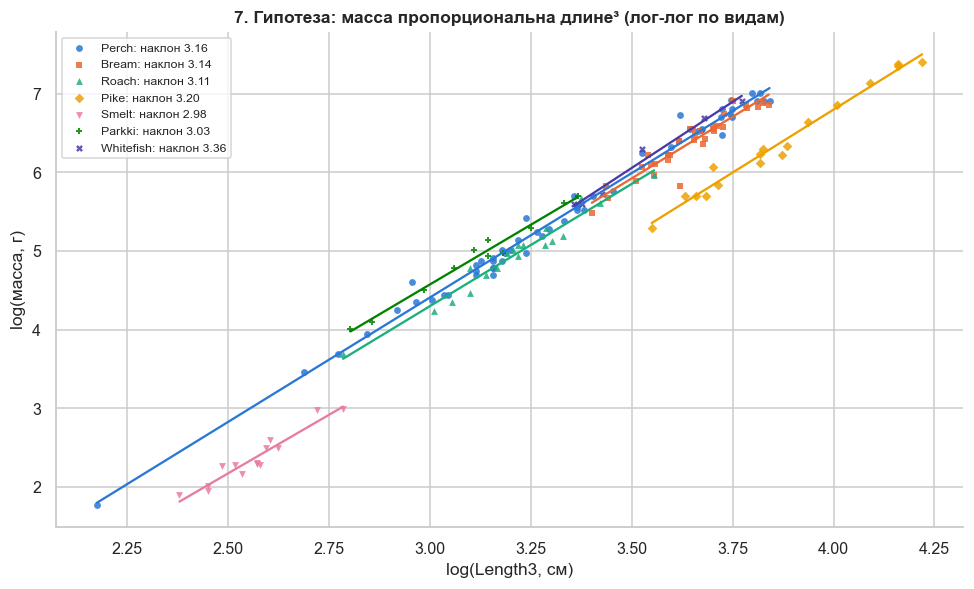

Perch        3.16
Bream        3.14
Roach        3.11
Pike         3.20
Smelt        2.98
Parkki       3.03
Whitefish    3.36
Name: наклон b, dtype: float64

In [25]:
pos = df[df["Weight"] > 0]          # log(0) не определён — строка 40 исключена
fig, ax = plt.subplots(figsize=(9, 5.5))
slopes = {}
for s in SPECIES_ORDER:
    part = pos[pos["Species"] == s]
    x, y = np.log(part["Length3"]), np.log(part["Weight"])
    b, a = np.polyfit(x, y, 1)
    slopes[s] = b
    ax.scatter(x, y, s=20, color=PALETTE[s], marker=MARKERS[s], alpha=0.85, linewidths=0,
               label=f"{s}: наклон {b:.2f}")
    xs = np.linspace(x.min(), x.max(), 10)
    ax.plot(xs, a + b * xs, color=PALETTE[s], lw=1.5)
ax.set(title="7. Гипотеза: масса пропорциональна длине³ (лог-лог по видам)",
       xlabel="log(Length3, см)", ylabel="log(масса, г)")
ax.legend(fontsize=8)
fig.tight_layout(); save(fig, "07_loglog_hypothesis"); plt.show()
pd.Series(slopes, name="наклон b").round(2)

**Вывод.** В лог-лог координатах зависимость массы от длины близка
к линейной для всех видов. Наклоны лежат в диапазоне 2.98-3.36, т. е.
близко к 3, что подтверждает гипотезу «масса пропорциональна длине³»
(при росте рыба в основном сохраняет форму). Прямые разных видов смещены
по вертикали: при равной длине виды различаются массой из-за формы тела.
Оценки для Whitefish (6 рыб) и Parkki (11) ненадёжны из-за малого числа
наблюдений. Строка 40 исключена (логарифм нуля не определён).
Следствие для модели: использовать log(масса), log(длины) и вид.

## 4. Выбросы: IQR и MAD

## 5. Гипотезы о признаках

## 6. Разбиение и утечки

## 7. Выводы